In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [ ]:
df = pd.read_csv('model_results/metric_results.csv', index_col=0)
df_timeseries = pd.read_csv('model_results/metric_results_unique_id.csv', index_col=0)
df_timeseries_h1 = pd.read_csv('model_results/metric_results_unique_id_h1.csv', index_col=0)
num_timeseries = {'amazon-google':20, 'glucose':16, 'm5':70, 'meditation':6, 'police': 5, 'patents': 83}
metrics = ['mase', 'mpiqr', 'pce', 'cce']
metric_names = ['MASE', "SIW", "PCE", "CCE"]
# metrics = ['stce_10', 'stce_90', 'cce_80', 'tce_80']
# metrics = ['stce_10', 'stce_90', 'pce', 'tce_80']
datasets = ['amazon-google', 'meditation', 'm5', 'glucose']
dataset_names = ['Reviews', 'Heart Rate', 'M5', 'Glucose']
datasets = ['amazon-google', 'glucose', 'police', 'patents']
dataset_names = ['Reviews', 'Glucose', 'police', 'patents']
# models = ['timesfm', 'moirai', 'chronos', 'lag-llama-context', 'nbeats-context', 'autoarima']
# model_names = ['TimesFM', 'MOIRAI', 'Chronos', 'Lag-Llama', 'NBEATS', 'AutoARIMA']
models = ['timesfm', 'moirai' , 'chronos-bolt_top_k', 'chronos_top_k', 'lag-llama-context', 'nbeats-config', 'autoarima']
model_names = ['TimesFM', 'MOIRAI', 'Chronos-Bolt', 'Chronos', 'Lag-Llama', 'NBEATS', 'AutoARIMA']
# models = ['timesfm', 'moirai' , 'chronos-bolt_top_k', 'chronos_top_k', 'lag-llama-context', 'nbeats-context', 'nbeats-context-normal']
# model_names = ['TimesFM', 'MOIRAI', 'Chronos-Bolt', 'Chronos', 'Lag-Llama', 'NBEATS', 'NBEATS (Normal)']
# model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(models)]
model_colors = ['#1b9e77','#d95f02','#7570b3','#e7298a','#1f77b4','#e6ab02', '#a6761d'][:len(models)]
dataset_markers = ['o', 'v', '*', 'P']
confidences = [20,40,60,80]
df

,dataset,model,metric,avg_result,1,2,3,4,5,6,...,39,40,41,42,43,44,45,46,47,48
0,amazon-google,timesfm,mase,0.626710,0.430666,0.500570,0.533389,0.549497,0.558109,0.564419,...,0.670660,0.664018,0.669928,0.669465,0.672305,0.673199,0.673113,0.677770,0.674093,0.671572
1,amazon-google,timesfm,wql,39.109267,0.569183,0.662820,0.702529,0.721602,0.731187,0.739626,...,0.863626,0.857371,0.862537,0.861212,0.865427,0.868556,0.868471,0.873211,0.866997,0.864564
2,amazon-google,timesfm,pce,0.030145,0.011274,0.008685,0.008188,0.009611,0.020062,0.007527,...,0.044444,0.035854,0.028807,0.038803,0.031653,0.039035,0.032485,0.037123,0.037474,0.035948
3,amazon-google,timesfm,mpiqr,0.179825,0.147943,0.158860,0.164309,0.170129,0.172340,0.173008,...,0.189807,0.187360,0.187184,0.188618,0.186606,0.184370,0.186646,0.186430,0.185243,0.189342
4,amazon-google,timesfm,tce_80,0.014083,0.013927,0.014583,0.008565,0.006713,0.007330,0.004514,...,0.020023,0.015355,0.010648,0.020293,0.012654,0.016165,0.014738,0.015779,0.013580,0.015123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2519,patents,autoarima,msis_20,27.987137,2.222234,2.770337,3.282393,4.010463,4.572922,5.163219,...,47.470544,49.077907,50.719000,52.210857,53.784785,55.423786,57.031612,58.642395,60.261341,61.867153
2520,patents,autoarima,mpiqr_20,0.114667,0.020933,0.026282,0.031068,0.034928,0.038267,0.041259,...,0.171347,0.174973,0.178516,0.181984,0.185759,0.189518,0.193195,0.196794,0.200322,0.203781
2521,patents,autoarima,stce_40,-0.263582,-0.235372,-0.260426,-0.272140,-0.267470,-0.273731,-0.275598,...,-0.252960,-0.249790,-0.250258,-0.249531,-0.248382,-0.249671,-0.249882,-0.247156,-0.250177,-0.251549
2522,patents,autoarima,stce_60,0.078099,-0.121328,-0.094903,-0.073391,-0.048626,-0.030870,-0.015223,...,0.137246,0.140859,0.141639,0.144980,0.147042,0.150383,0.153386,0.149454,0.150815,0.152065


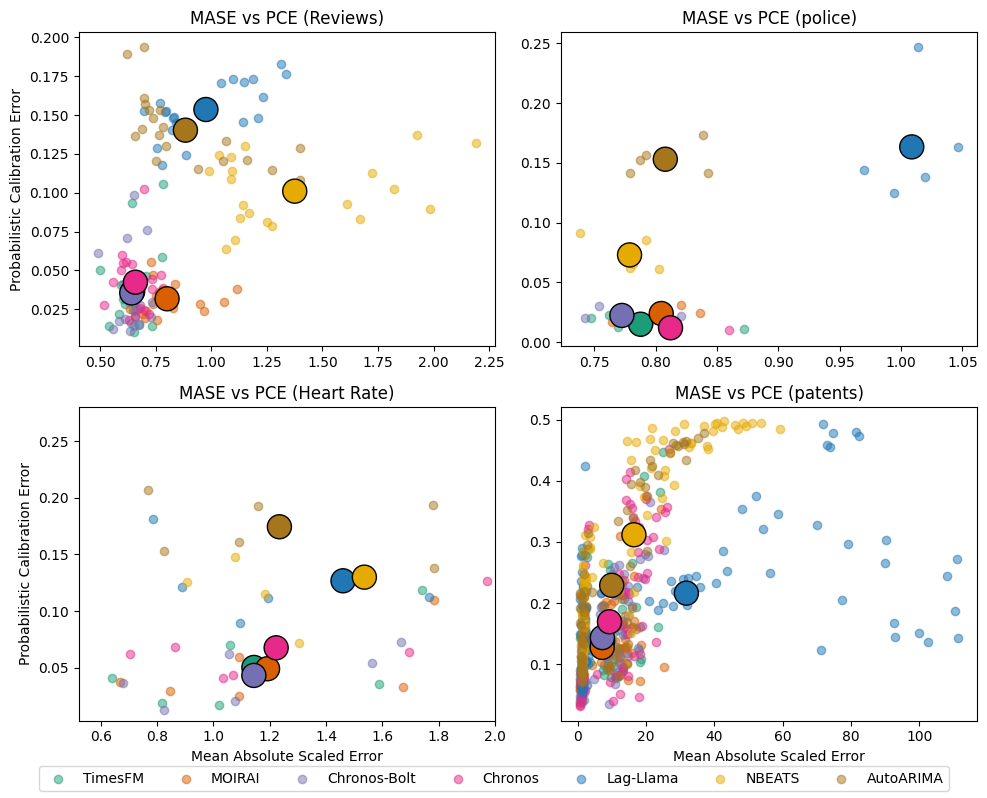

In [ ]:
# Figure #1 MASE vs PCE
fig, axes = plt.subplots(2, 2, figsize=(10,8))
for i, dataset in enumerate(datasets):
    ax = axes[i%2, i//2]
    x_means = []
    y_means = []
    for model_color, model, model_name in zip(model_colors, models, model_names):
        time_series_ind = [str(i) for i in range(1,num_timeseries[dataset]+1)]
        x = df_timeseries.loc[(df_timeseries['model']==model) & (df_timeseries['dataset']==dataset) & (df_timeseries['metric']=='mase'), time_series_ind]
        y = df_timeseries.loc[(df_timeseries['model']==model) & (df_timeseries['dataset']==dataset) & (df_timeseries['metric']=='pce'), time_series_ind]
        ax.scatter(x, y, c=model_color, label=model_name, alpha=0.5)
        x_means.append(np.mean(x))
        y_means.append(np.mean(y))
    
    ax.scatter(x_means, y_means, c=model_colors, s=300, edgecolors='black', alpha=1)
    if i%2 == 1:
        ax.set_xlabel('Mean Absolute Scaled Error')
    if i//2 == 0:
        ax.set_ylabel('Probabilistic Calibration Error')
    ax.set_title(f'MASE vs PCE ({dataset_names[i]})')
    # ax.legend(loc='upper left', ncols=3)
    if dataset == 'm5':
        ax.set_xlim(right=2)
    elif dataset == 'meditation':
        ax.set_xlim(right=2)
        ax.set_ylim(top=0.28)
    elif dataset == 'glucose':
        ax.set_xlim(right=11)
handles, labels = ax.get_legend_handles_labels()
plt.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, loc='lower center', ncols=7)
# fig.suptitle("MASE VS PCE")

plt.savefig(f'figures/scatter_plot_mase_pce.png')
plt.show()

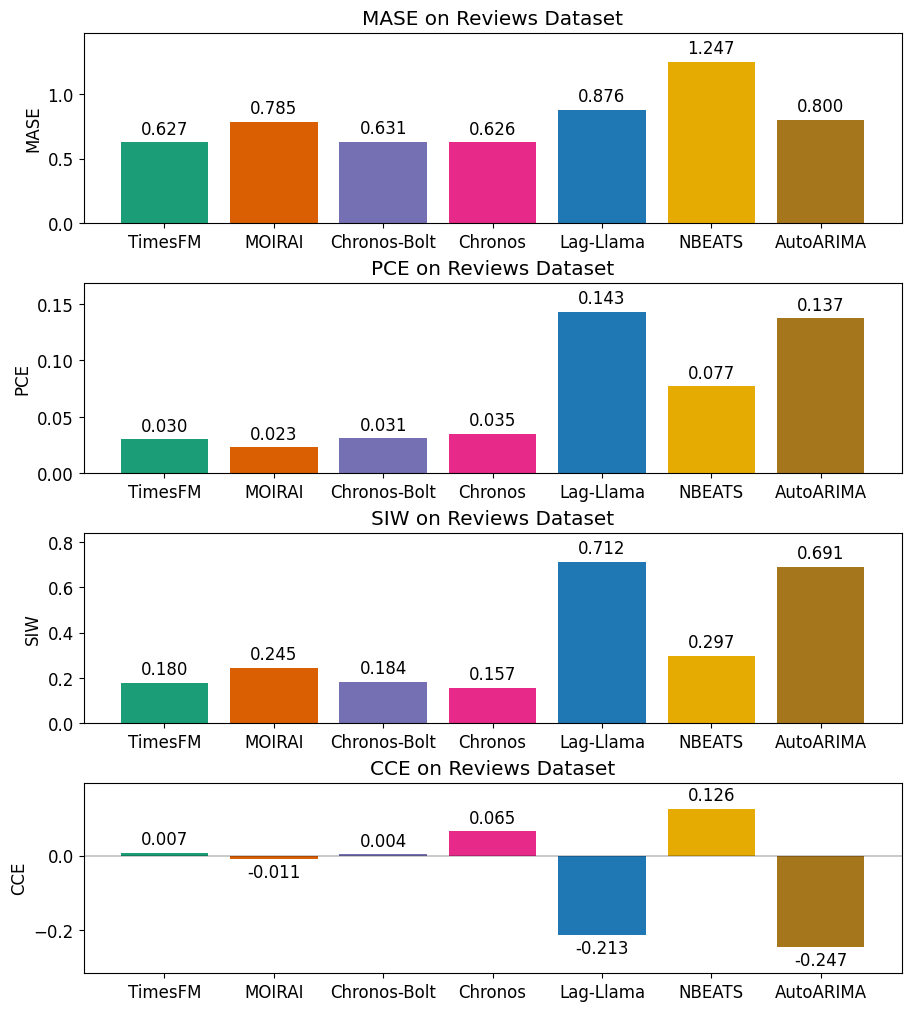

In [4]:
# Figure #2 All metrics bar plot (Reviews)
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(4, layout='constrained', figsize=(9,10))
h = 'avg_result'
metrics = ['mase', 'pce', 'mpiqr', 'cce']
metric_names = ['MASE', 'PCE', 'SIW', 'CCE']
for i, metric in enumerate(metrics):
    if metric == 'mase':
        n_datasets = 3
    else: 
        n_datasets = 4
    ax = axes[i]
    multiplier = 0
    # for model_color, model_name, model in zip(model_colors, model_names, models):
    values = [df.loc[(df['model']==model) & (df['dataset']=='amazon-google') & (df['metric']==metric), h].item() for model in models]
        # offset = width * multiplier - width*(len(models)/2-1.5)
        # rects = ax.bar(x[:n_datasets] + offset, values, width, label=model_name, color=model_color)
    rects = ax.bar(model_names, values, color=model_colors)
    ax.bar_label(rects, padding=3, fmt='%.3f')

    if 'cce' in metric:
        ax.axhline(0, c='black', lw=0.3)

    ax.set_ylabel(metric_names[i])
    ax.set_title(f'{metric_names[i]} on Reviews Dataset')    
    bottom, top = ax.get_ylim()
    ax.set_ylim(top=top+(top-bottom)/8, bottom=bottom if bottom == 0 else bottom-(top-bottom)/8)
handles, labels = ax.get_legend_handles_labels()
plt.savefig('figures/bar_plot_metrics_reviews.png')
plt.show()

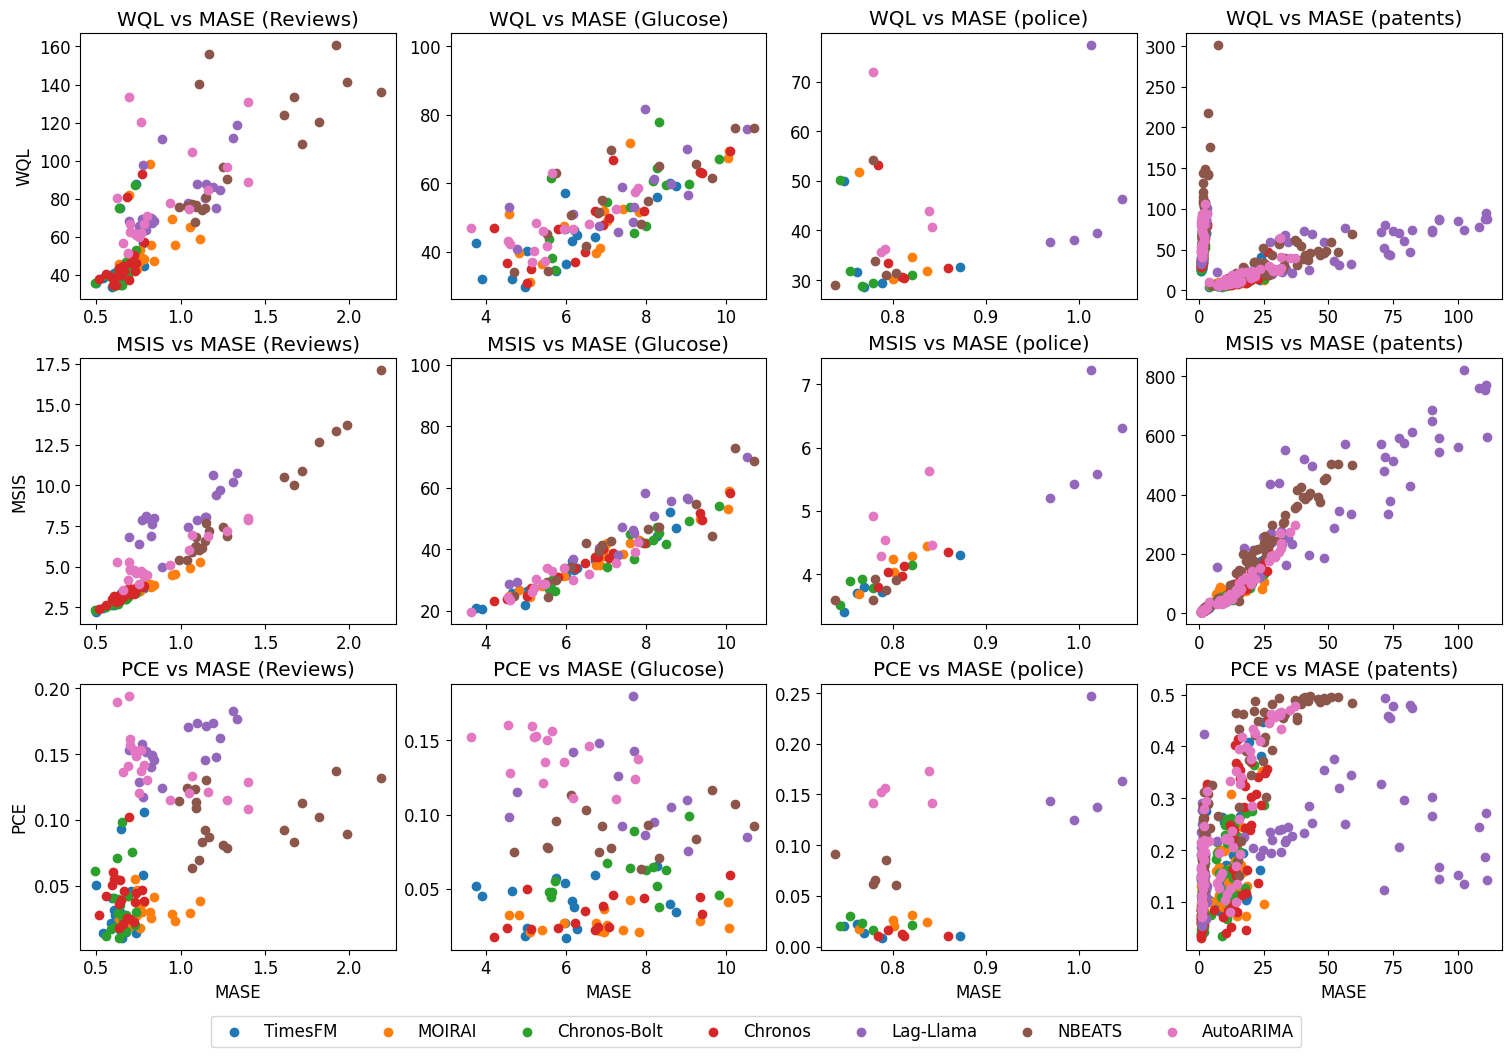

In [18]:
# Figure #3 WQL,MSIS,PCE vs MASE comparison (scatter plot)

metrics = ['wql', 'msis_80', 'pce']
metric_names = ['WQL', "MSIS", "PCE"]

fig, axes = plt.subplots(3, 4, layout='constrained', figsize=(15,10))
for i, (dataset_name, dataset) in enumerate(zip(dataset_names, datasets)):
    time_series_ind = [str(h) for h in range(1,num_timeseries[dataset]+1)]
    for j, metric_y in enumerate(metrics):
        ax = axes[j, i]
        for model, model_name in zip(models, model_names):
            x = df_timeseries.loc[(df_timeseries['model']==model) & (df_timeseries['dataset']==dataset) & (df_timeseries['metric']=='mase'), time_series_ind]
            y = df_timeseries.loc[(df_timeseries['model']==model) & (df_timeseries['dataset']==dataset) & (df_timeseries['metric']==metric_y), time_series_ind]
            ax.scatter(x, y, label=model_name)
        if i == 0:
            ax.set_ylabel(metric_names[j])
        if j==2:
            ax.set_xlabel('MASE')

        if dataset == 'glucose':
            ax.set_xlim(right=11)
        if dataset == 'm5':
            ax.set_xlim(right=3)
        if dataset == 'meditation':
            ax.set_xlim(right=2.5)
        ax.set_title(f'{metric_names[j]} vs MASE ({dataset_name})')
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.05), loc='lower center', ncols=7)
plt.savefig(f'figures/scatter_plot_calibration_correlation.png')
plt.show()

/tmp/ipykernel_1982399/2301131614.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.02, 1, 1])


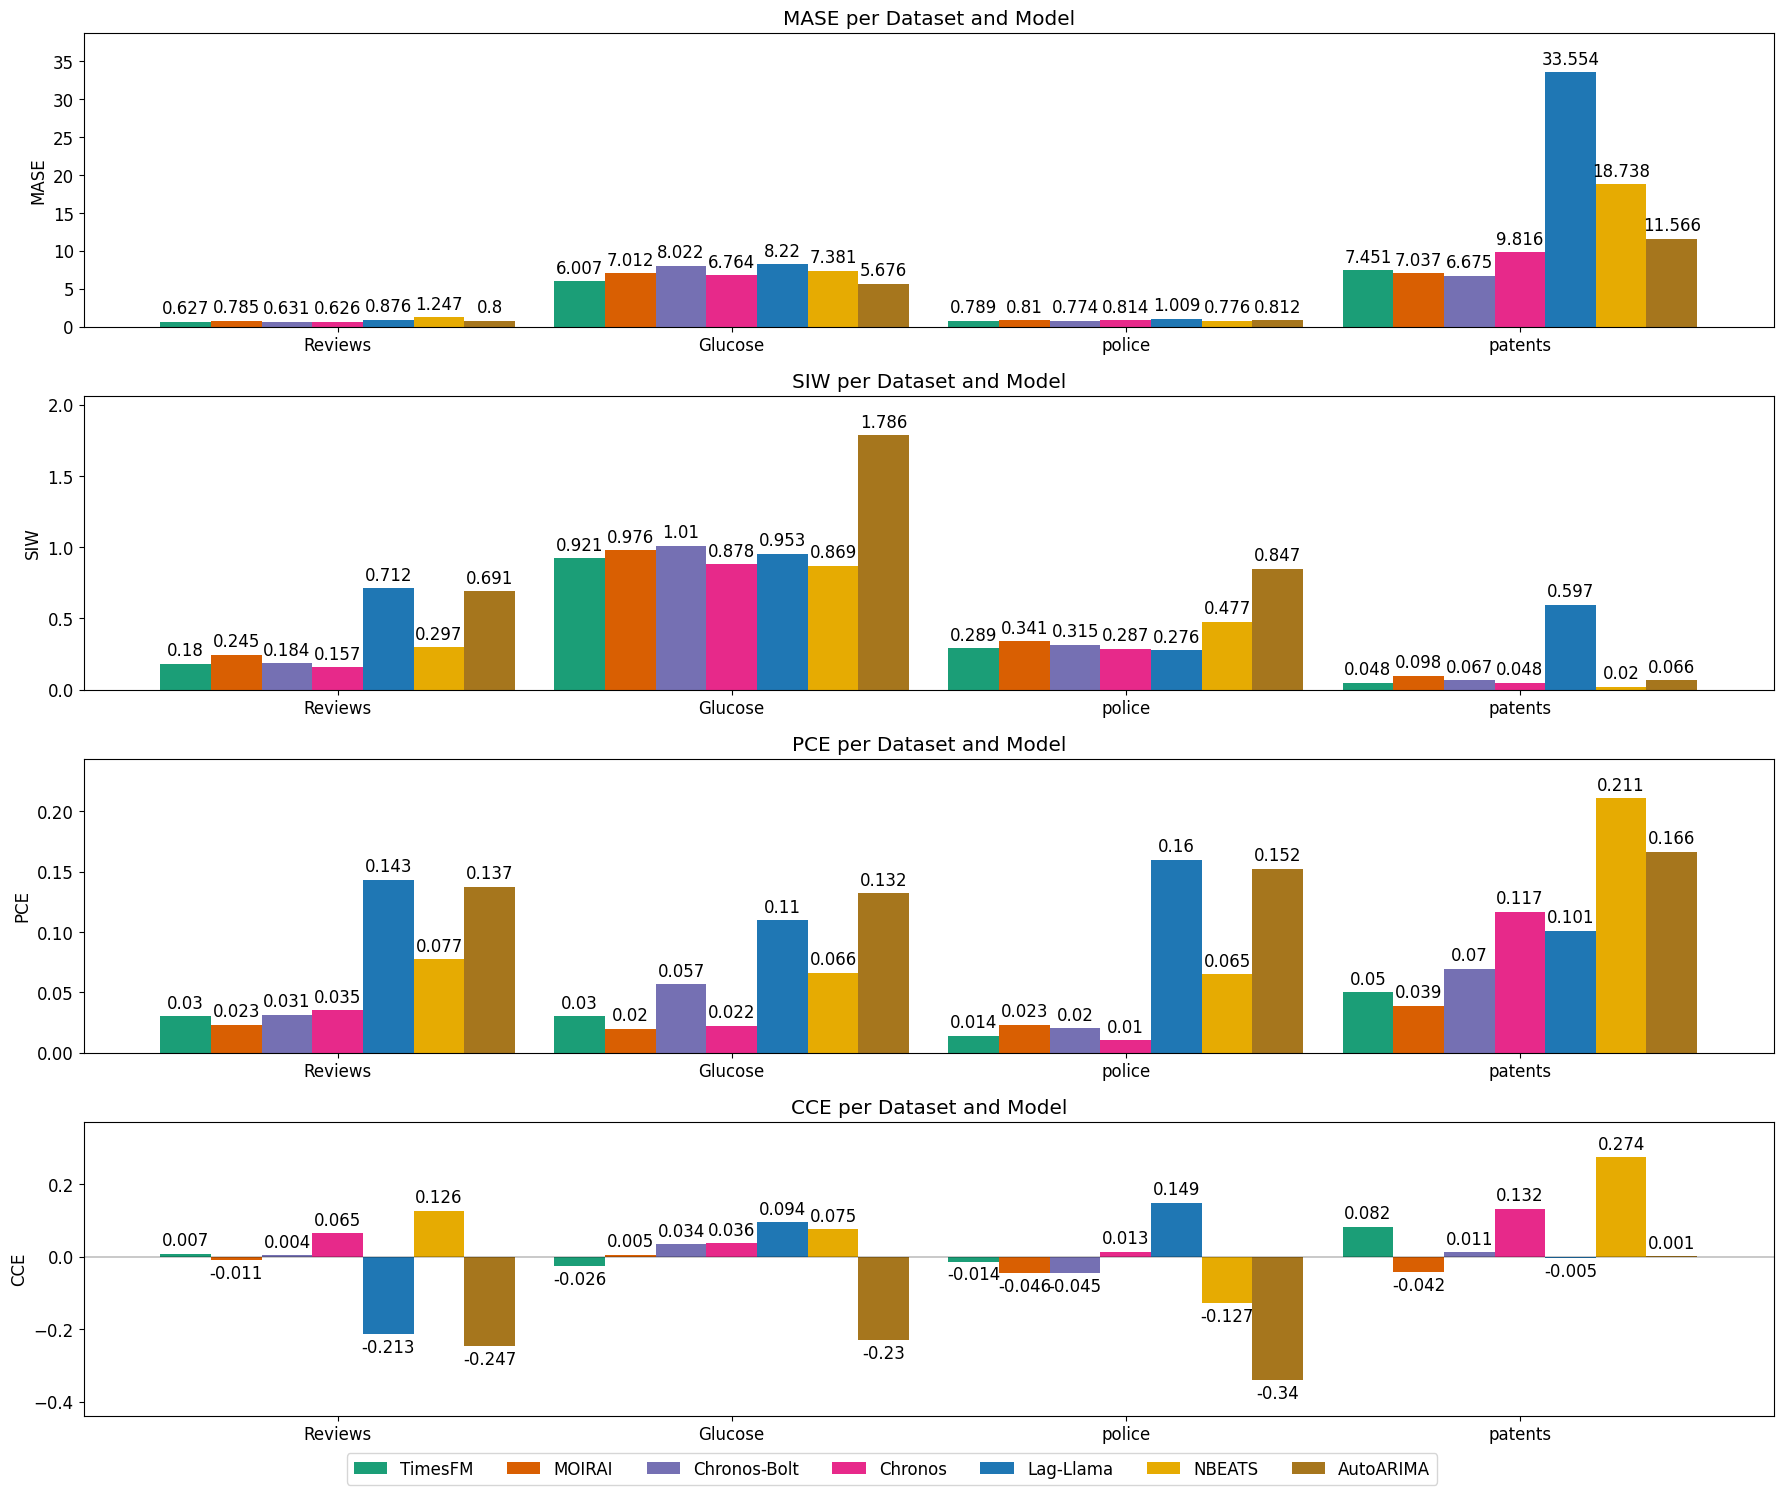

In [19]:
# Figure #4 MASE, SIW, PCE, CCE across all models/datasets
fig, axes = plt.subplots(4, layout='constrained', figsize=(18,15))
width = 0.15 * 6/7
x = np.arange(len(datasets))
wql_top = 0.03
h = 'avg_result'
new_metrics = ['mase', 'mpiqr', 'pce', 'cce']
new_metric_names = ['MASE', 'SIW', 'PCE', 'CCE']

for i, metric in enumerate(new_metrics):
    ax = axes[i]
    if metric == 'mase' and metrics[-1] == ['glucose']:
        scaler = np.array([1,1,1,1/6])
        ax.axvline(np.average(x[-2:] + width), c='black', lw=1, ls=':')
    else: 
        scaler = np.array([1,1,1,1])
    multiplier = 0
    for model_color, model_name, model in zip(model_colors, model_names, models):
        values = np.array([df.loc[(df['model']==model) & (df['dataset']==dataset) & (df['metric']==metric), h].item() for dataset in datasets])
        offset = width * multiplier - width*(len(models)/2-1.5)
        rects = ax.bar(x + offset, values * scaler, width, label=model_name, color=model_color)
        if metric == 'mase' and metrics[-1] == ['glucose']:
            bar = matplotlib.container.BarContainer(rects[:-1], None, datavalues=np.round(values[:-1],3), orientation='vertical')
            ax.bar_label(bar, np.round(values[:-1],3), padding=3, c='black')
            bar = matplotlib.container.BarContainer(rects[-1:], None, datavalues=np.round(values[-1:],3), orientation='vertical')
            ax.bar_label(bar, np.round(values[-1:],3), padding=3, c='blue')
        else:
            ax.bar_label(rects, np.round(values,3), padding=3, c='black')
        multiplier += 1

    if 'cce' in metric:
        ax.axhline(0, c='black', lw=0.3)

    ax.set_ylabel(new_metric_names[i])
    ax.set_title(f'{new_metric_names[i]} per Dataset and Model')
    ax.set_xticks(x + width, dataset_names)
    
    bottom, top = ax.get_ylim()
    ax.set_ylim(top=top+(top-bottom)/10, bottom=bottom if bottom == 0 else bottom-(top-bottom)/10)
    if metric == 'mase' and metrics[-1] == ['glucose']:
        axright = ax.twinx()
        axright.set_ylim(top=(top+(top-bottom)/10)/scaler[-1], bottom=bottom)
        axright.tick_params(axis='y', labelcolor='blue')
plt.tight_layout(rect=[0, 0.02, 1, 1])
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=7)
plt.savefig('figures/bar_plot_all.png')
plt.show()

/tmp/ipykernel_1982399/3535729570.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.02, 1, 1])


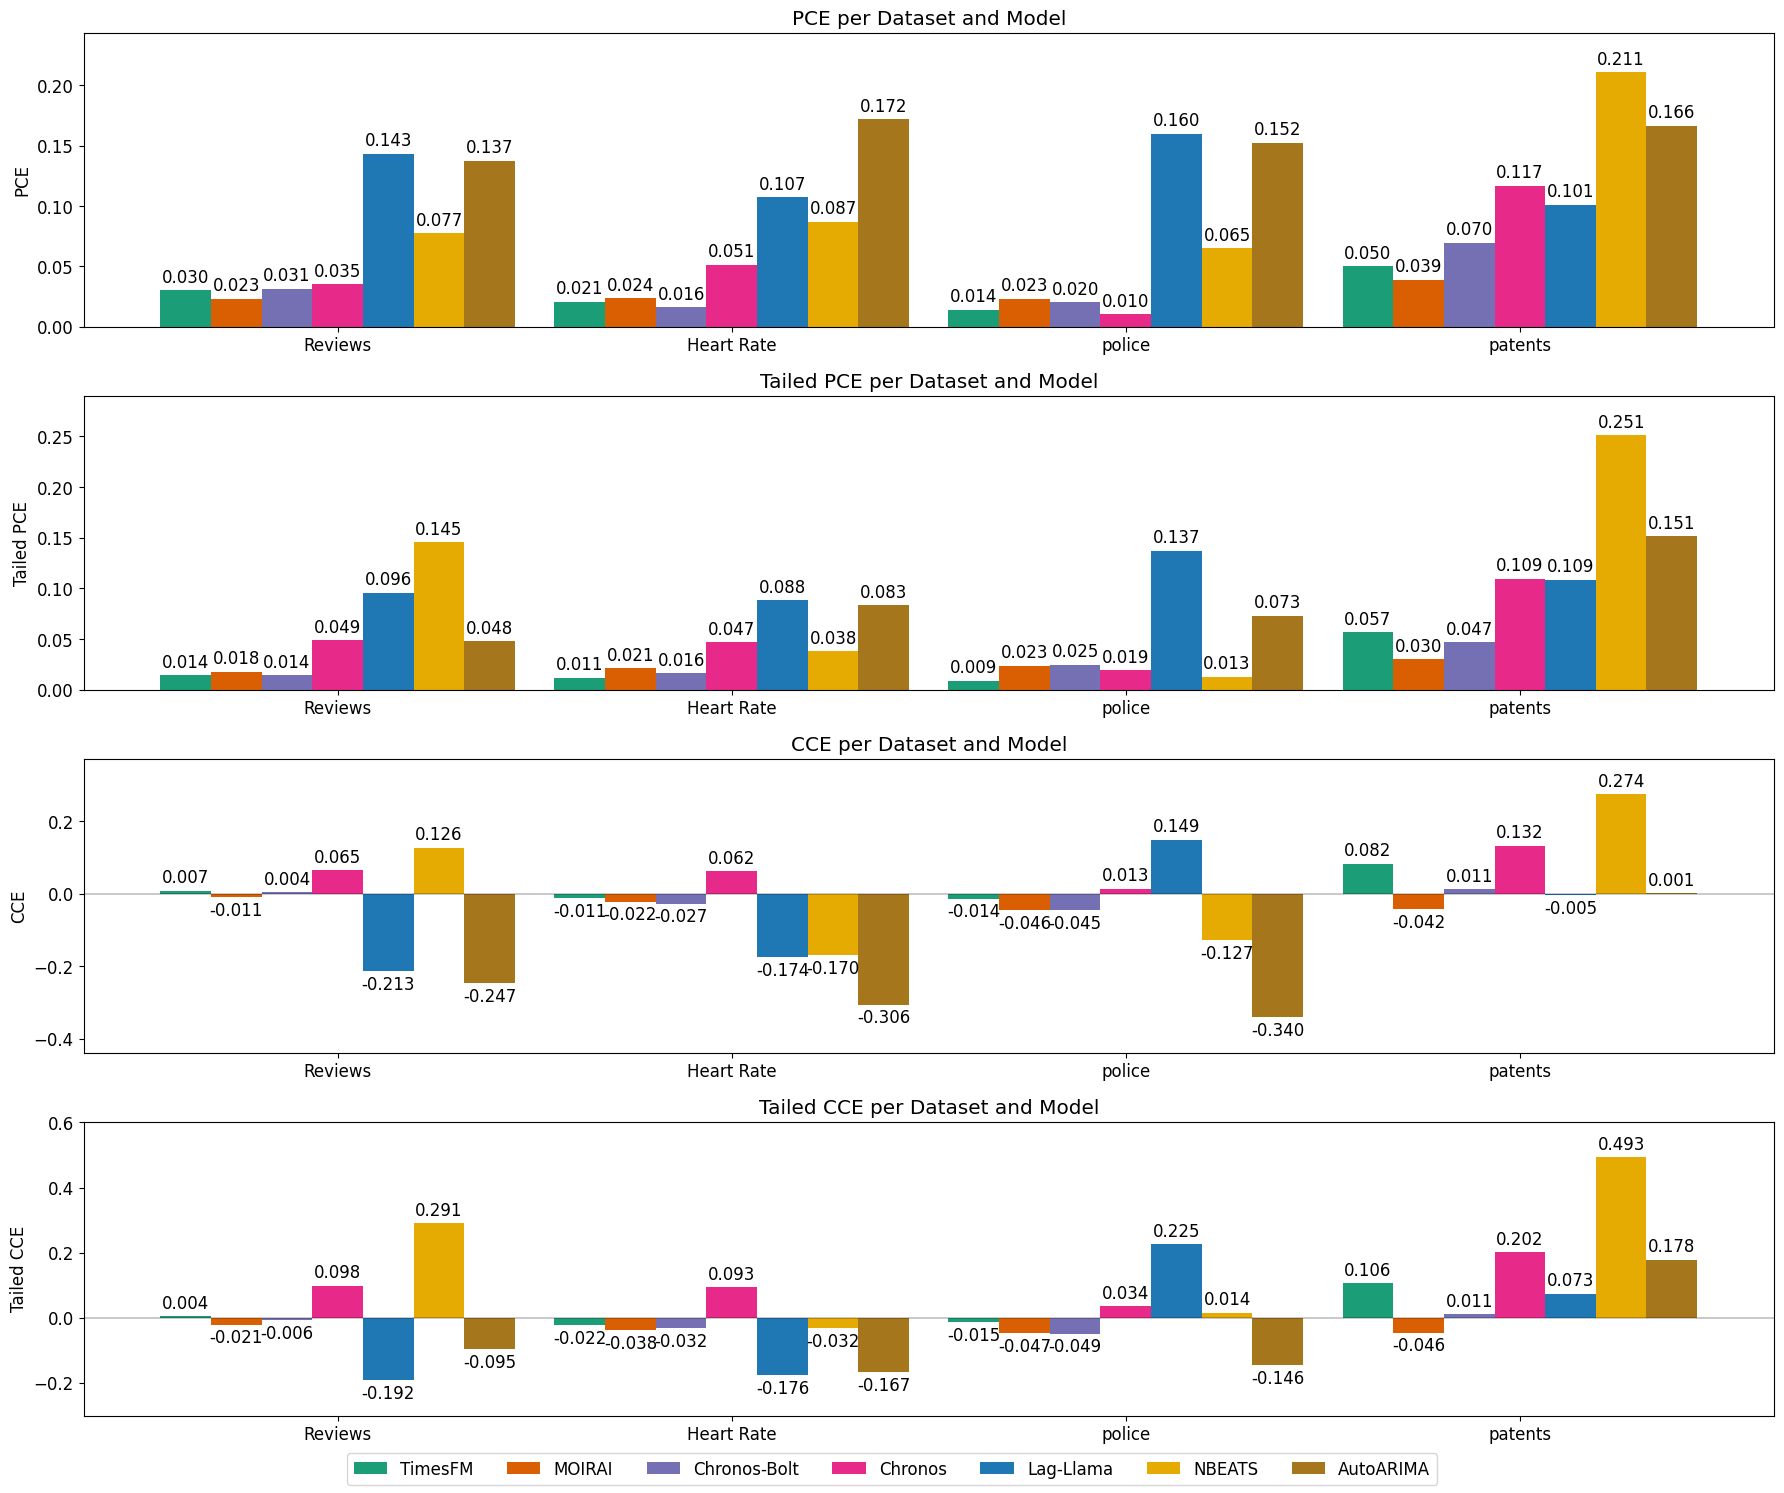

In [7]:
# Figure #5 Calibration of tail distribution
fig, axes = plt.subplots(4, layout='constrained', figsize=(18,15))
width = 0.15 * 6/7
x = np.arange(len(datasets))
wql_top = 0.03
h = 'avg_result'
new_metrics = ['pce', 'tce_80', 'cce', 'cce_80']
new_metric_names = ['PCE', 'Tailed PCE', 'CCE', 'Tailed CCE']

for i, metric in enumerate(new_metrics):
    ax = axes[i]
    multiplier = 0
    for model_color, model_name, model in zip(model_colors, model_names, models):
        values = [df.loc[(df['model']==model) & (df['dataset']==dataset) & (df['metric']==metric), h].item() for dataset in datasets[:n_datasets]]
        offset = width * multiplier - width*(len(models)/2-1.5)
        rects = ax.bar(x[:n_datasets] + offset, values, width, label=model_name, color=model_color)
        ax.bar_label(rects, padding=3, fmt='%.3f')
        multiplier += 1

    if 'cce' in metric:
        ax.axhline(0, c='black', lw=0.3)

    ax.set_ylabel(new_metric_names[i])
    ax.set_title(f'{new_metric_names[i]} per Dataset and Model')
    ax.set_xticks(x[:n_datasets] + width, dataset_names[:n_datasets])
    # ax.legend(loc='upper left', ncols=3)    
    bottom, top = ax.get_ylim()
    ax.set_ylim(top=top+(top-bottom)/10, bottom=bottom if bottom == 0 else bottom-(top-bottom)/10)
handles, labels = ax.get_legend_handles_labels()
plt.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, loc='lower center', ncols=7)
plt.savefig('figures/bar_plot_tailed_calibration.png')
plt.show()

/tmp/ipykernel_1982399/2187117050.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.02, 1, 1])


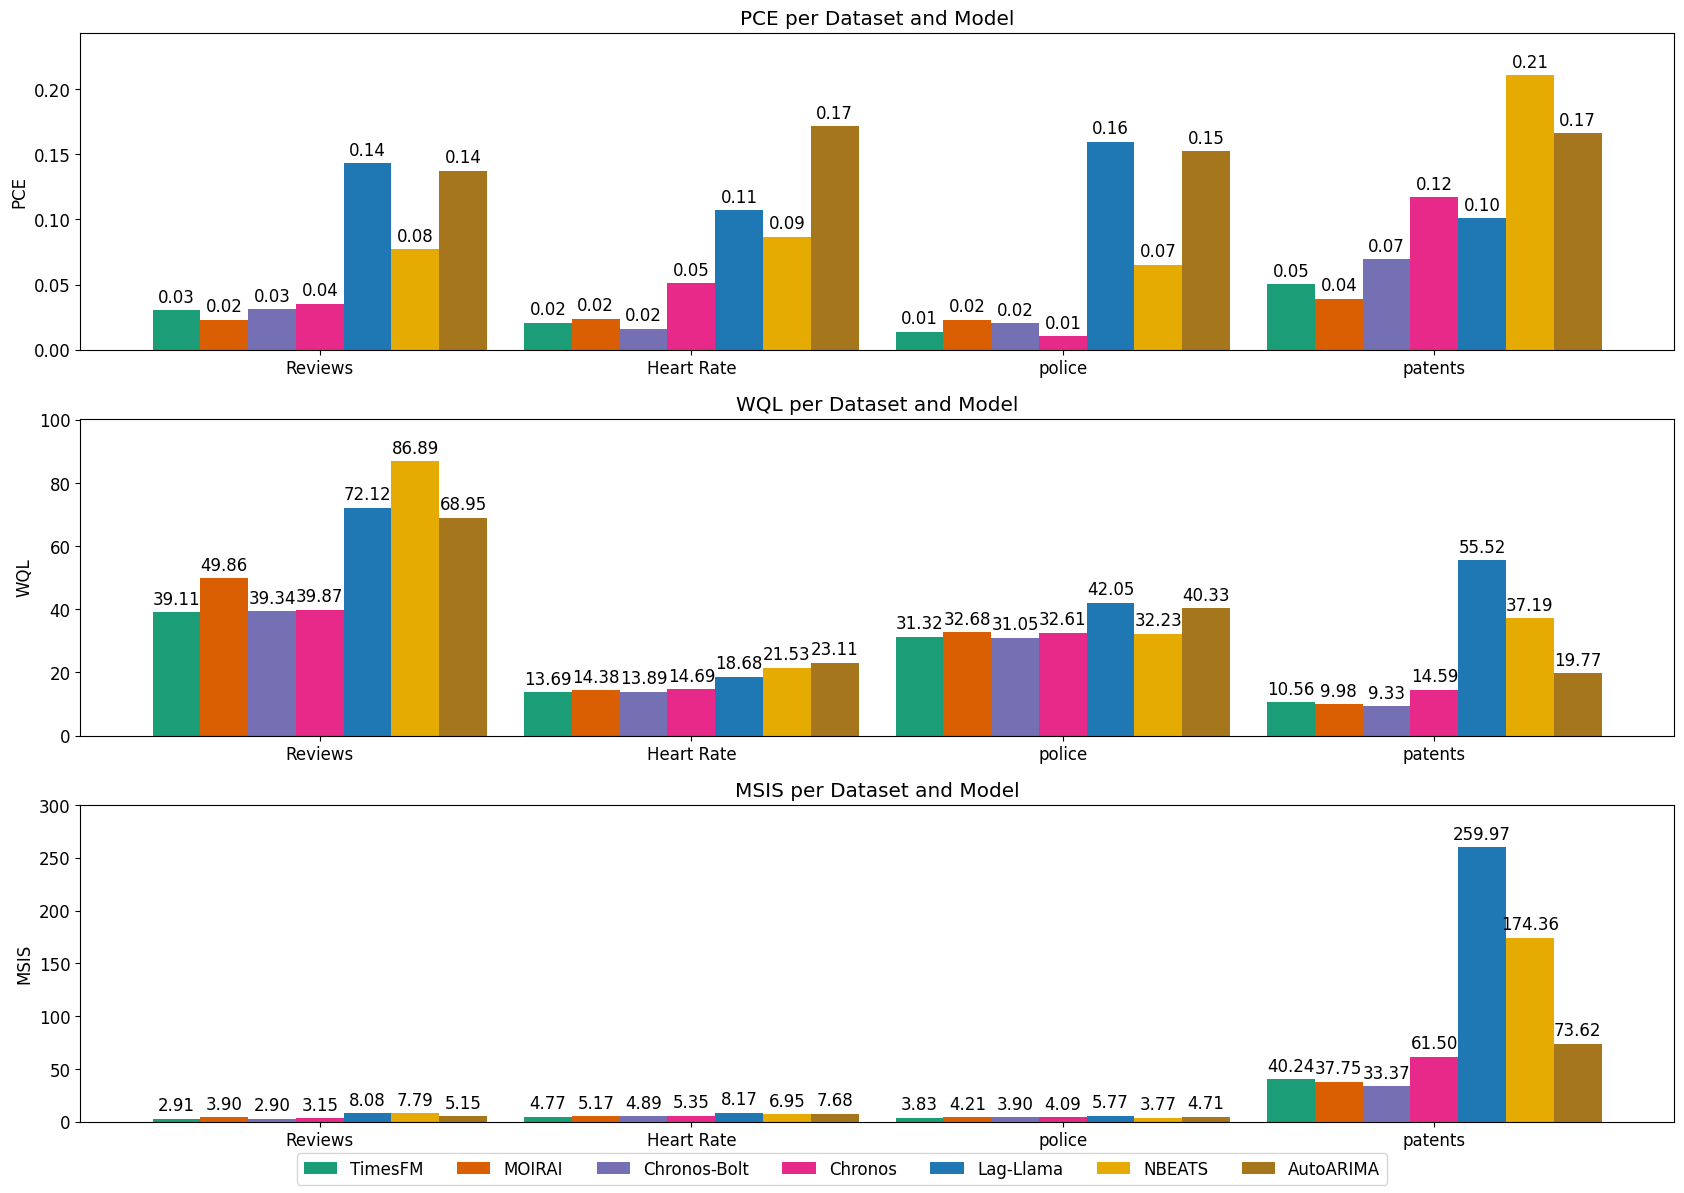

In [8]:
# Figure #6 PCE vs WQL, MSIS Bar plots
fig, axes = plt.subplots(3, layout='constrained', figsize=(17,12))
width = 0.15 * 6/7
x = np.arange(len(datasets))
wql_top = 0.03
h = 'avg_result'

metrics = ['pce', 'wql', 'msis_80']
metric_names = ['PCE', 'WQL', "MSIS"]

for i, metric in enumerate(metrics):
    if metric == 'mase':
        n_datasets = 3
    else: 
        n_datasets = 4
    ax = axes[i]
    multiplier = 0
    for model_color, model_name, model in zip(model_colors, model_names, models):
        values = [df.loc[(df['model']==model) & (df['dataset']==dataset) & (df['metric']==metric), h].item() for dataset in datasets[:n_datasets]]
        offset = width * multiplier - width*(len(models)/2-1.5)
        rects = ax.bar(x[:n_datasets] + offset, values, width, label=model_name, color=model_color)
        ax.bar_label(rects, padding=3, fmt='%.2f')
        multiplier += 1

    if 'cce' in metric:
        ax.axhline(0, c='black', lw=0.3)

    ax.set_ylabel(metric_names[i])
    ax.set_title(f'{metric_names[i]} per Dataset and Model')
    ax.set_xticks(x[:n_datasets] + width, dataset_names[:n_datasets])
    # ax.legend(loc='upper left', ncols=3)
    bottom, top = ax.get_ylim()
    ax.set_ylim(top=top+(top-bottom)/10, bottom=bottom if bottom == 0 else bottom-(top-bottom)/10)
handles, labels = ax.get_legend_handles_labels()
plt.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, loc='lower center', ncols=7)
plt.savefig('figures/bar_plot_calibration_metrics.png')
plt.show()

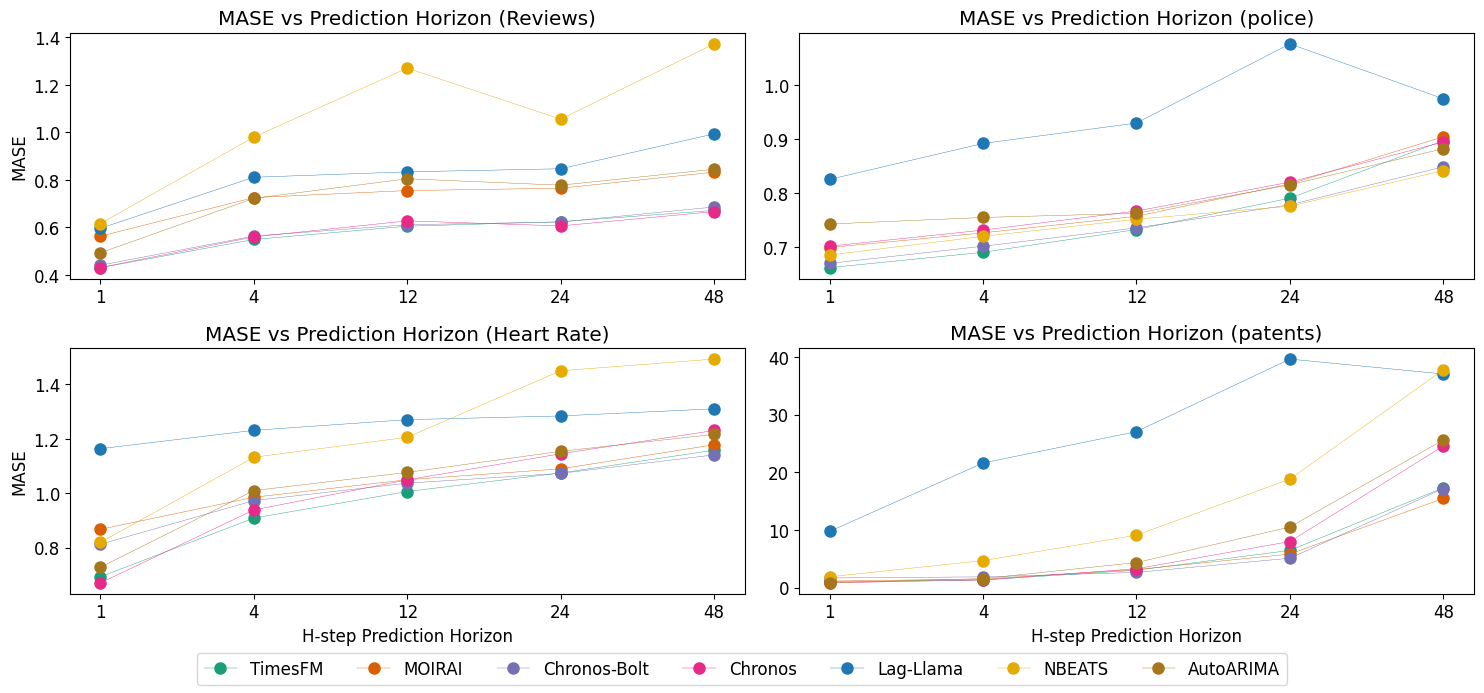

In [9]:
# Figure #7 MASE across forecast horizon
pred_horizon = ['1','4','12','24','48']
# dataset = 'amazon-google'

fig, axes = plt.subplots(2, 2, layout='tight' , figsize=(15,7))
for i, dataset in enumerate(datasets):
    ax = axes[i%2, i//2]
    for model_color, model, model_name in zip(model_colors, models, model_names):
        y = df.loc[(df['model']==model) & (df['dataset']==dataset) & (df['metric']=='mase'), pred_horizon].to_numpy().flatten()
        ax.plot(np.arange(len(pred_horizon)), y, label=model_name, marker='o', lw=0.3, c=model_color, markersize=8)

    # Add some text for labels, title and custom x-axis tick labels, etc.   
    ax.set_title(f'MASE vs Prediction Horizon ({dataset_names[i]})')
    ax.set_xticks(np.arange(len(pred_horizon)), pred_horizon)
    if i%2 == 1:
        ax.set_xlabel("H-step Prediction Horizon")
    if i//2 == 0:
        ax.set_ylabel('MASE')
    # ax.legend(loc='upper left', ncols=3)
handles, labels = ax.get_legend_handles_labels()
plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.legend(handles, labels, loc='lower center', ncols=7)

plt.savefig(f'figures/line_plot_mase.png')
plt.show()

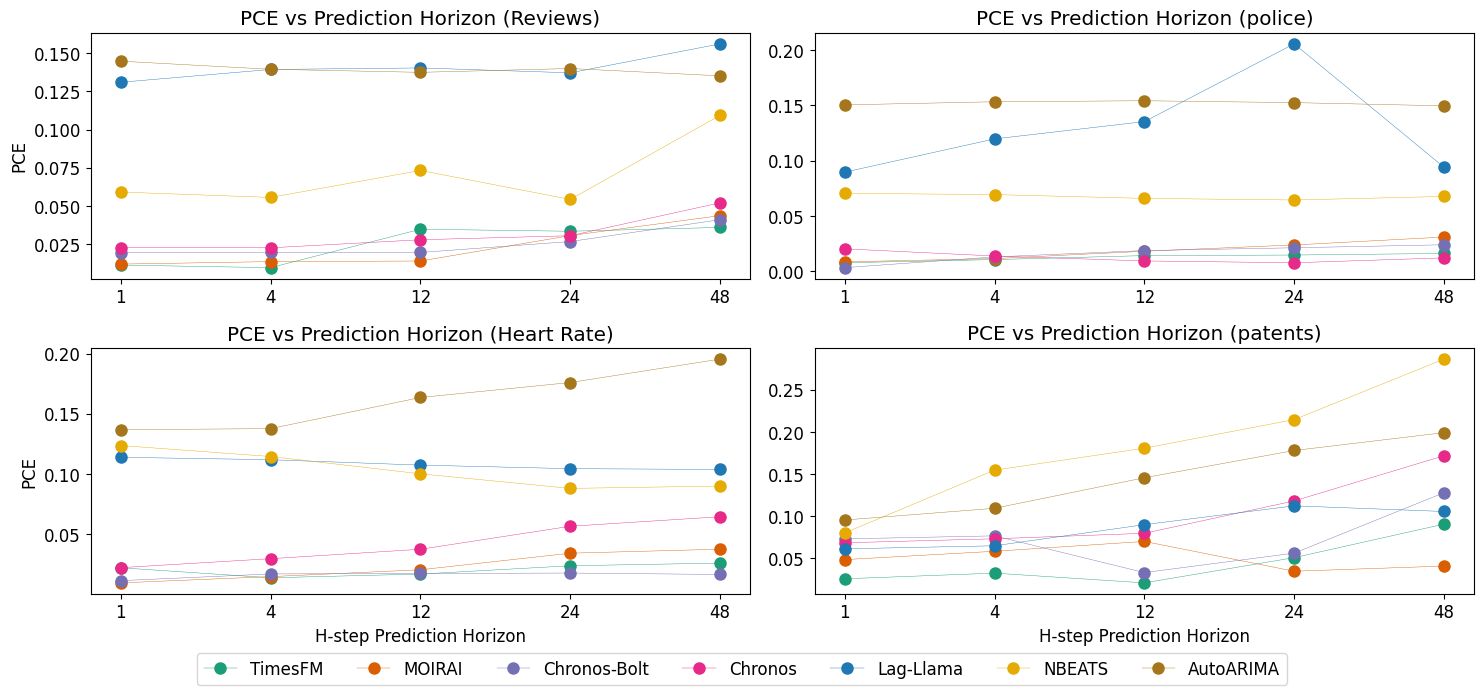

In [10]:
# Figure #8 PCE across forecast horizon
pred_horizon = ['1','4','12','24','48']
# dataset = 'amazon-google'

fig, axes = plt.subplots(2, 2, layout='tight' , figsize=(15,7))
for i, dataset in enumerate(datasets):
    ax = axes[i%2, i//2]
    for model_color, model, model_name in zip(model_colors, models, model_names):
        y = df.loc[(df['model']==model) & (df['dataset']==dataset) & (df['metric']=='pce'), pred_horizon].to_numpy().flatten()
        ax.plot(np.arange(len(pred_horizon)), y, label=model_name, marker='o', lw=0.3, c=model_color, markersize=8)

    # Add some text for labels, title and custom x-axis tick labels, etc.   
    ax.set_title(f'PCE vs Prediction Horizon ({dataset_names[i]})')
    ax.set_xticks(np.arange(len(pred_horizon)), pred_horizon)
    if i%2 == 1:
        ax.set_xlabel("H-step Prediction Horizon")
    if i//2 == 0:
        ax.set_ylabel('PCE')
    # ax.legend(loc='upper left', ncols=3)
handles, labels = ax.get_legend_handles_labels()
plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.legend(handles, labels, loc='lower center', ncols=7)

plt.savefig(f'figures/line_plot_horizon_pce.png')
plt.show()

In [11]:
df.loc[(df['model']=='chronos_top_k') & (df['dataset']=='glucose') & (df['metric']=='pce'), ['1','48']]

,1,48
1512,0.04256,0.021257


/tmp/ipykernel_1982399/3590096013.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.02, 1, 1])


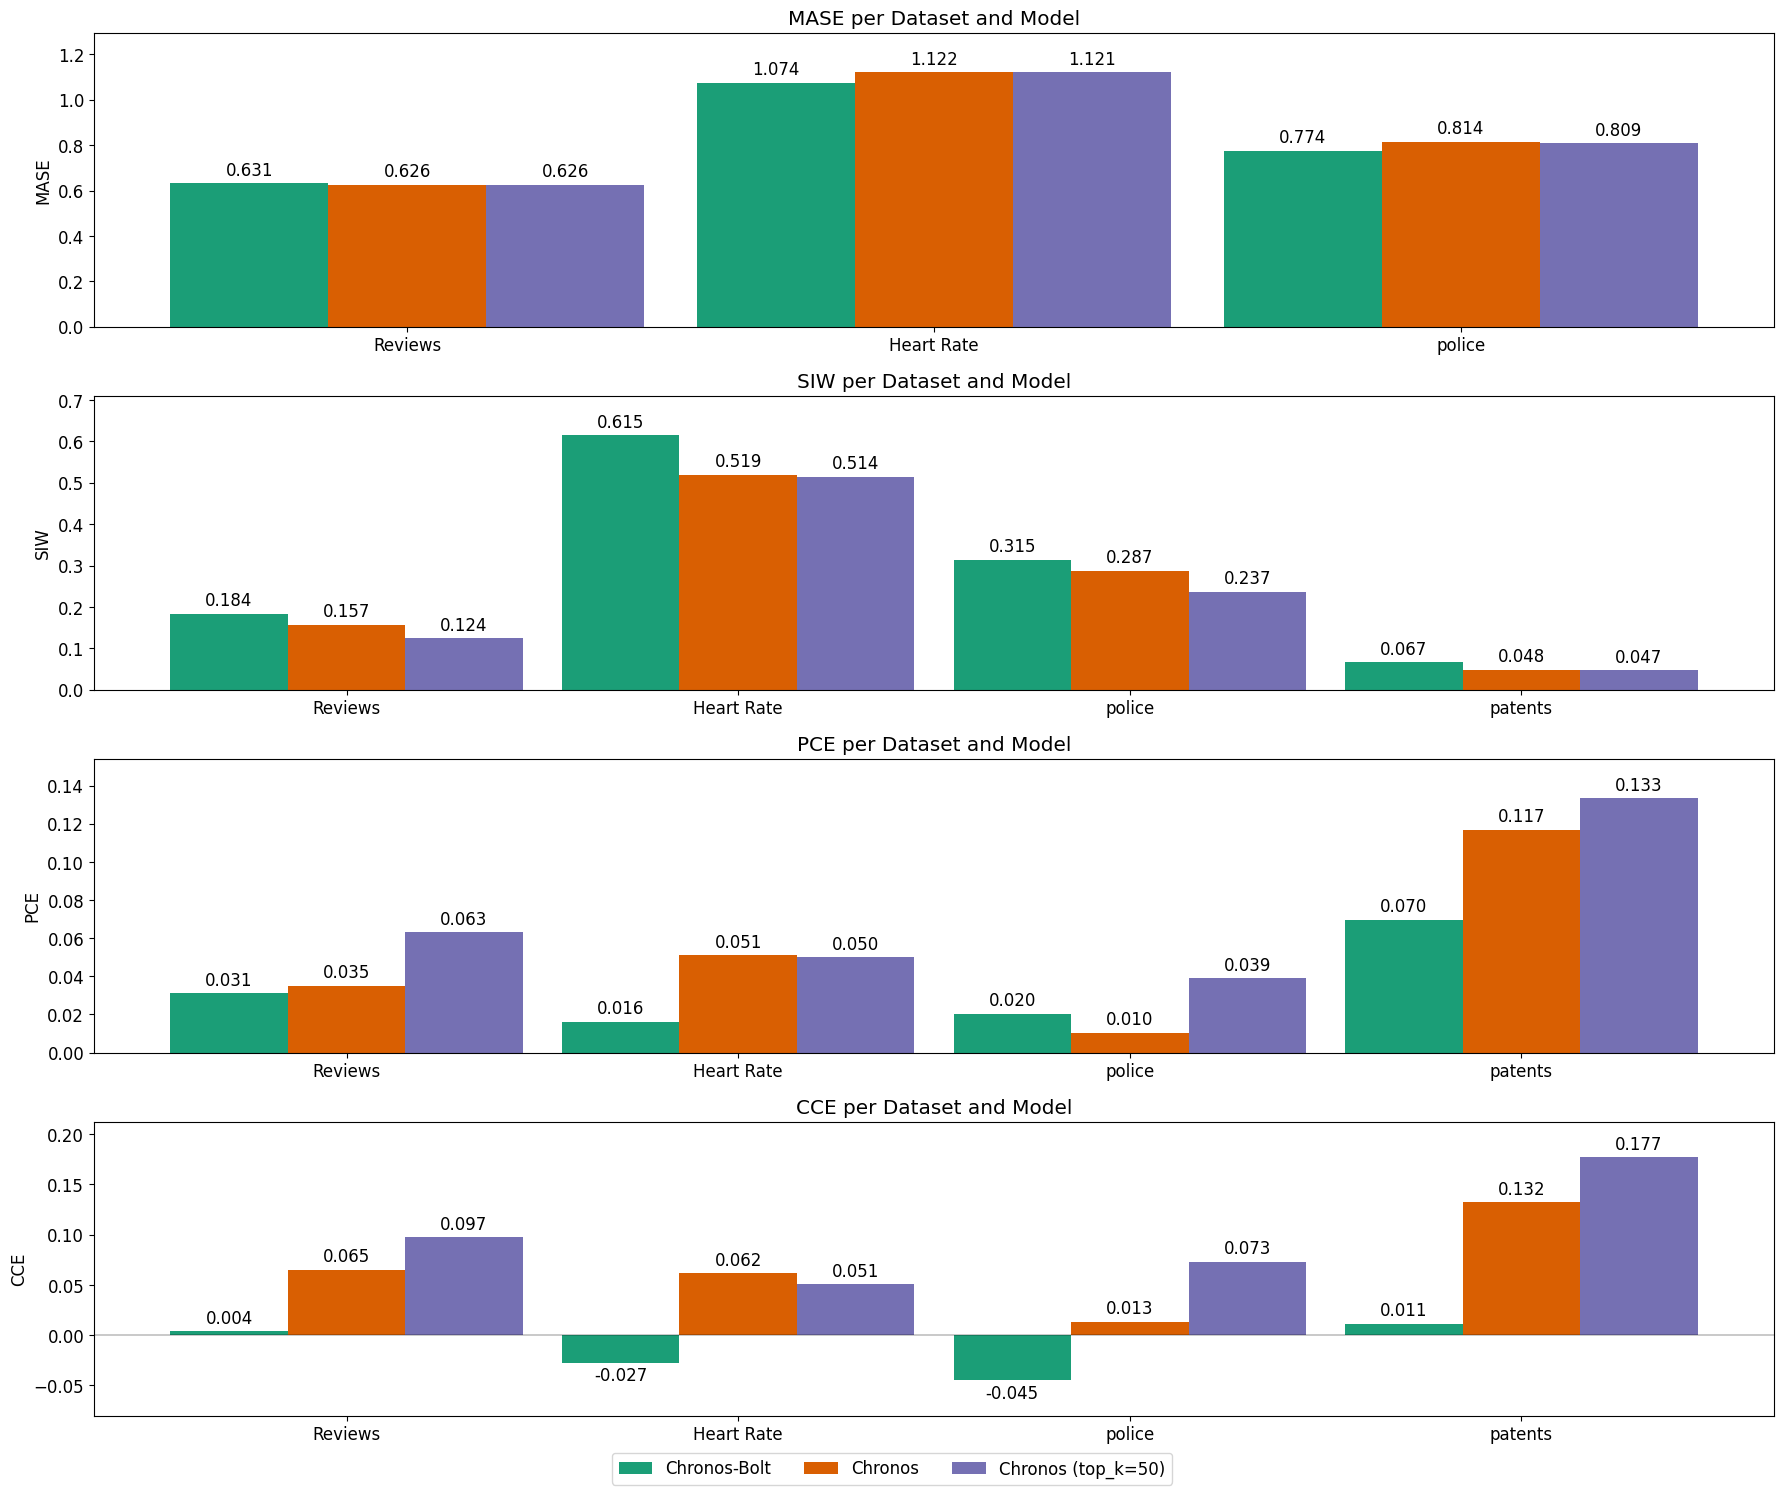

In [12]:
# Figure #9 MASE, SIW, PCE, CCE across all chronos models_chronos
models_chronos = ['chronos-bolt_top_k', 'chronos_top_k', 'chronos']
model_names_chronos = ['Chronos-Bolt', 'Chronos', 'Chronos (top_k=50)']
model_colors_chronos = ['#1b9e77','#d95f02','#7570b3','#e7298a','#1f77b4','#e6ab02', '#a6761d'][:len(models_chronos)]

fig, axes = plt.subplots(4, layout='constrained', figsize=(18,15))
width = 0.15 * 6/3
x = np.arange(len(datasets))
wql_top = 0.03
h = 'avg_result'
new_metrics = ['mase', 'mpiqr', 'pce', 'cce']
new_metric_names = ['MASE', 'SIW', 'PCE', 'CCE']

for i, metric in enumerate(new_metrics):
    if metric == 'mase':
        n_datasets = 3
    else: 
        n_datasets = 4
    ax = axes[i]
    multiplier = 0
    for model_color, model_name, model in zip(model_colors_chronos, model_names_chronos, models_chronos):
        values = [df.loc[(df['model']==model) & (df['dataset']==dataset) & (df['metric']==metric), h].item() for dataset in datasets[:n_datasets]]
        offset = width * multiplier - width*(len(models_chronos)/2-1.5)
        rects = ax.bar(x[:n_datasets] + offset, values, width, label=model_name, color=model_color)
        ax.bar_label(rects, padding=3, fmt='%.3f')
        multiplier += 1

    if 'cce' in metric:
        ax.axhline(0, c='black', lw=0.3)

    ax.set_ylabel(new_metric_names[i])
    ax.set_title(f'{new_metric_names[i]} per Dataset and Model')
    ax.set_xticks(x[:n_datasets] + width, dataset_names[:n_datasets])
    bottom, top = ax.get_ylim()
    ax.set_ylim(top=top+(top-bottom)/10, bottom=bottom if bottom == 0 else bottom-(top-bottom)/10)
plt.tight_layout(rect=[0, 0.02, 1, 1])
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncols=3)
plt.savefig('figures/bar_plot_all_chronos.png')
plt.show()

In [13]:
# Table #1 Calibration evaluation results
datasets_new = ['amazon-google', 'm5', 'glucose', 'meditation']
dataset_names_new = ['Reviews', 'M5', 'Glucose', 'Heart-Rate']
for metric in ['mase', 'pce', 'cce', 'mpiqr', 'wql']:
    print(metric)
    for dataset, dataset_name in zip(datasets_new, dataset_names_new):
        vals = []
        for model in models:
            vals.append(df.loc[(df['metric']=='wql') & (df['model']==model) & (df['dataset']==dataset), 'avg_result'].item())
        prefix = [''] * len(models)
        prefix[np.argmin(vals)] = '\\textbf'
        prefix[np.argsort(vals)[1]] = '\\underline'
        print(f"& {{{dataset_name}}} & {prefix[0]}{{{vals[0]:.3f}}} & {prefix[1]}{{{vals[1]:.3f}}} & {prefix[2]}{{{vals[2]:.3f}}} & {prefix[3]}{{{vals[3]:.3f}}} & {prefix[4]}{{{vals[4]:.3f}}} & {prefix[5]}{{{vals[5]:.3f}}} & {prefix[6]}{{{vals[6]:.3f}}} \\\\")

mase
& {Reviews} & \textbf{39.109} & {49.857} & \underline{39.343} & {39.870} & {72.120} & {86.890} & {68.954} \\
& {M5} & \underline{45.662} & {51.980} & \textbf{45.561} & {49.168} & {79.341} & {48.126} & {55.722} \\
& {Glucose} & \textbf{44.348} & {51.463} & {58.524} & {49.627} & {63.292} & {55.980} & \underline{47.378} \\
& {Heart-Rate} & \textbf{13.690} & {14.379} & \underline{13.887} & {14.686} & {18.677} & {21.530} & {23.110} \\
pce
& {Reviews} & \textbf{39.109} & {49.857} & \underline{39.343} & {39.870} & {72.120} & {86.890} & {68.954} \\
& {M5} & \underline{45.662} & {51.980} & \textbf{45.561} & {49.168} & {79.341} & {48.126} & {55.722} \\
& {Glucose} & \textbf{44.348} & {51.463} & {58.524} & {49.627} & {63.292} & {55.980} & \underline{47.378} \\
& {Heart-Rate} & \textbf{13.690} & {14.379} & \underline{13.887} & {14.686} & {18.677} & {21.530} & {23.110} \\
cce
& {Reviews} & \textbf{39.109} & {49.857} & \underline{39.343} & {39.870} & {72.120} & {86.890} & {68.954} \\
& {M5} & \